# Visualize the latent space of networks using UMAP

This notebook shows how to
- Compute network outputs at internal layers of the network
- Visualize those outputs using UMAP

In [1]:
# reload modules before executing code in order to make development and debugging easier
%load_ext autoreload
%autoreload 2

In [2]:
# this jupyter notebook is running inside of the "notebooks" directory
# for relative paths to work properly, we need to set the current working directory to the root of the project
# for imports to work properly, we need to add the code folder to the system path
import os
from os.path import abspath, join, isdir, isfile
import sys
if not isdir("notebooks"):
    # if there's a "notebooks" directory in the cwd, we've already set the cwd so no need to do it again
    os.chdir("../bin")
os.getcwd()
module_path = abspath("bin")
if module_path not in sys.path:
    sys.path.append(module_path)
os.getcwd()

'/home/server/Desktop/projects/CYPpred/bin'

In [3]:
import torch
import build_model
import utils
import umap
import encode as enc
import constants
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

In [4]:
# 加载数据并编码
ds = utils.load_dataset(ds_fn='../data/cyp2c9/cyp2c9_dg.tsv')  # 以 pandas 格式加载数据集

wt_aa = constants.DATASETS["cyp2c9"]["wt_aa"]  # 野生氨基酸序列
wt_ofs = constants.DATASETS["cyp2c9"]["wt_ofs"]

# create the dataset dictionary, containing encoded data, scores, etc,
data = {}
vk = ['score_GG', 'score_GA', 'score_AA']
data["scores"] = []

data["ds"] = ds
data["variants"] = ds['variant'].tolist()
for i in vk:
    data["scores"].append(ds[f"{i}"].to_numpy(dtype='float32'))
data["scores"] = np.array(np.array(data["scores"]).flatten().tolist(), dtype=np.float32)
data["encoded_data"] = enc.encode(encoding='one_hot,aa_index', graph_fn="",
                                  variants=data["variants"],
                                  wt_aa=wt_aa, wt_offset=wt_ofs)

In [5]:
# 加载模型
loaded_model = torch.load('./output/cnn_3X128_full_model.pth', weights_only=False)
loaded_model.eval()

GCNdp6(
  (conv1_1): Conv1d(43, 128, kernel_size=(13,), stride=(1,), padding=(1,))
  (conv1_2): Conv1d(128, 128, kernel_size=(13,), stride=(1,), padding=(1,))
  (conv1_3): Conv1d(128, 128, kernel_size=(13,), stride=(1,), padding=(1,))
  (conv2_1): Conv1d(43, 128, kernel_size=(13,), stride=(1,), padding=(1,))
  (conv2_2): Conv1d(128, 128, kernel_size=(13,), stride=(1,), padding=(1,))
  (conv2_3): Conv1d(128, 128, kernel_size=(13,), stride=(1,), padding=(1,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dropout): Dropout(p=0.1, inplace=False)
  (bn1_1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn1_2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn1_3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2_1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tr

In [19]:
def extract_features(loaded_model, dataloader, device):
    features_dict = {'layer1': [], 'layer2': [], 'layer3': [], 'layer_cat':[]}
    labels = []
    
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)  # (batch_size, 490, 40)
            _, features = loaded_model(x, return_features=True)
            for layer in features:
                # 展平特征 (batch_size, channels, length) -> (batch_size, -1)
                flattened = features[layer].view(x.size(0), -1).cpu().numpy()
                features_dict[layer].append(flattened)
            labels.append(y.cpu().numpy())
    
    # 合并所有batch
    for layer in features_dict:
        features_dict[layer] = np.concatenate(features_dict[layer], axis=0)
    labels = np.concatenate(labels)
    
    return features_dict, labels

def apply_umap(features_dict):
    umap_results = {}
    for layer, feats in features_dict.items():
        # UMAP降维
        reducer = umap.UMAP(n_components=2, random_state=7)
        umap_results[layer] = reducer.fit_transform(feats)
    return umap_results

def plot_umap(umap_results, labels, title_suffix=""):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.ravel()
    for (layer, emb), ax in zip(umap_results.items(), axes):
        divnorm = colors.TwoSlopeNorm(vmin=labels.min(), vcenter=3.25, vmax=labels.max())
        scatter = ax.scatter(emb[:, 0], emb[:, 1], c=labels, cmap="coolwarm", norm=divnorm, s=2, alpha=0.5, marker="o", linewidth=0)
        # ax.set_title(f'UMAP - {layer} {title_suffix}')
        fig.colorbar(scatter, ax=ax)
        plt.savefig('./data/cyp2c9/figure/umap.png', dpi=300, bbox_inches='tight')
    plt.show()

/home/server/anaconda3/envs/CYP_torch/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/server/anaconda3/envs/CYP_torch/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/server/anaconda3/envs/CYP_torch/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/server/anaconda3/envs/CYP_torch/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/server/anaconda3/envs/CYP_torch/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting rand

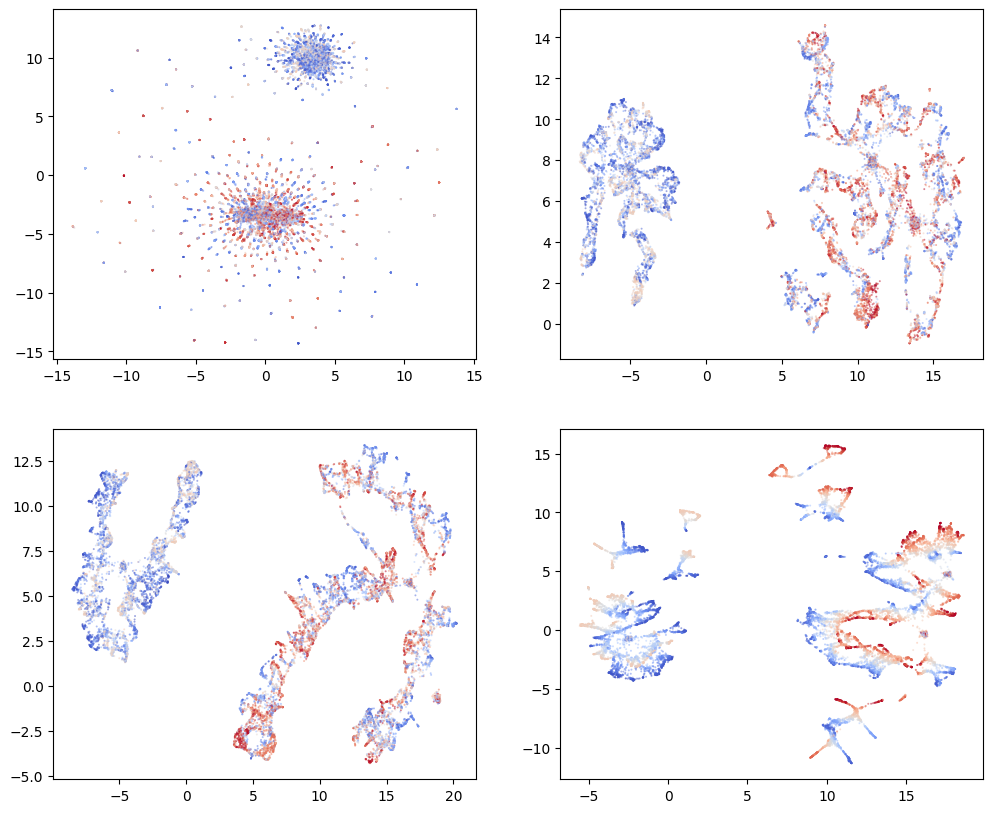

In [20]:
# 将数据转换为迭代器加载到GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# set the encoded data to its own var to make things cleaner
train_loader = utils.create_dataloader(torch.tensor(data["encoded_data"]["encoded_data"]),torch.tensor(data["scores"]),batch_size=16)

# 使用示例
features_dict, labels = extract_features(loaded_model, train_loader, device)
umap_results = apply_umap(features_dict)
plot_umap(umap_results, labels, "(cnn_3x128)")

# 可以改进的地方
   目前三层的卷积神经网络之间的输出，并没有明显的高维划分，也就是没有区别。头痛
随后在几天后训练出最优的模型之后，由于是双流的模型，可以尝试在相同的层中，不选择合并特征，而是直接输出，也就是说对于目前的三层卷积中，应该共有7个特征输出（6个三层卷积的计算，1个训练合并之后的计算），因此直接对这7个特征进行UMAP分析，查看有没有可用的结果，另外对于训练是选择五折交叉验证，因此没有明确的测试集和训练集，所以在几天后的最后输出的时候需要考虑这个问题，而且可以找到全连接中的100个神经元作分析